## Week 8 - Combining Different Models For Ensemble Learning
### `Goals`:
- Make predictions based on `majority voting`
- Use `bagging` to reduce overfitting by drawing random combinations of the training dataset with repetition
- Apply `boosting` to build powerful models from weak learners that leran from their mistakes.
- How the bagging reduce the `variance` but not the `bias`

##
##

### `Bagging`:
**Bagging**, short for **Bootstrap Aggregating**, is an ensemble machine learning technique designed to improve the stability and accuracy of machine learning algorithms. It reduces **variance** and helps prevent **overfitting**.

The core idea is to train multiple versions of the same model on different subsets of the training data and then combine their predictions.

---

### 1. How Bagging Works (Step-by-Step)

Bagging consists of two main processes: **Bootstrapping** and **Aggregating**.

#### Step A: Bootstrapping (Sampling)
Instead of training one model on the entire dataset, we create multiple subsets of the data. We do this using a technique called **Random Sampling with Replacement**:
*   Suppose you have a dataset of 100 rows.
*   You create "Bootstrap" samples by picking 100 rows at random, but after picking a row, you put it back into the pool before picking the next one.
*   This means some rows might appear multiple times in a single subset, while others might not appear at all.

#### Step B: Training
A separate model (usually of the same type, like a Decision Tree) is trained independently on each bootstrap sample. Because the datasets are slightly different, each model learns slightly different patterns.

#### Step C: Aggregating (Combining)
Once all models are trained, we collect their individual predictions to make a final decision:
*   **For Regression:** We take the **average** of all the predictions from the individual models.
*   **For Classification:** We use **majority voting** (the class that receives the most "votes" from the models becomes the final prediction).

---

### 2. Why Use Bagging? (Key Benefits)

1.  **Reduces Variance:** High-variance models (like deep Decision Trees) are prone to overfitting—they follow the noise in the data too closely. Bagging smooths out these fluctuations by averaging results.
2.  **Prevents Overfitting:** Because no single model sees the entire dataset and every model is slightly different, the ensemble is much less likely to overfit to outliers.
3.  **Handles High Dimensionality:** It works well when you have many features that might cause a single model to become unstable.

---

### 3. Bagging vs. Boosting

It is easy to confuse Bagging with **Boosting**. Here is the fundamental difference:

| Feature | Bagging | Boosting |
| :--- | :--- | :--- |
| **Goal** | Reduce **Variance** (prevent overfitting). | Reduce **Bias** (improve accuracy/underfitting). |
| **Model Training** | Models are trained in **parallel** (independently). | Models are trained **sequentially** (each model fixes the errors of the previous one). |
| **Data Usage** | Each model uses a random bootstrap sample. | Each new model focuses more on the "hard" cases that were misclassified previously. |
| **Example** | **Random Forest** | **AdaBoost, XGBoost, Gradient Boosting** |

---

### 4. The Most Famous Example: Random Forest

The most successful application of Bagging is the **Random Forest** algorithm. 

While standard Bagging only selects random subsets of *data*, Random Forest adds an extra layer of randomness: it also selects a **random subset of features** (columns) at each split in the decision tree. This ensures that the trees are even more decorrelated, making the final ensemble incredibly robust and powerful.

### Summary Table
| Component | Action |
| :--- | :--- |
| **Bootstrap** | Create multiple datasets via random sampling with replacement. |
| **Train** | Train one model per dataset in parallel. |
| **Aggregate** | Average (Regression) or Vote (Classification) to get the final result. |


---

##
##

### `Boosting`
**Boosting** is an ensemble machine learning technique that focuses on reducing **bias** and improving the accuracy of a model. 

Unlike Bagging, where models are trained independently in parallel, Boosting works **sequentially**. Each new model in the sequence attempts to correct the errors made by the previous models.

---

### 1. How Boosting Works (Step-by-Step)

The core philosophy of Boosting is: *"Learn from your mistakes."*

#### Step A: Initial Training
A simple "weak learner" (a model that performs only slightly better than random guessing, such as a very shallow Decision Tree) is trained on the entire dataset.

#### Step B: Error Identification
The algorithm looks at the predictions made by the first model and identifies which data points were predicted incorrectly (the residuals or errors).

#### Step C: Weight Adjustment (The "Boosting" Part)
This is the most critical step. The algorithm adjusts the dataset to focus on the mistakes:
*   **In AdaBoost:** The weights of the misclassified data points are **increased**. This makes the next model "pay more attention" to those specific difficult cases.
*   **In Gradient Boosting:** Instead of changing weights, the new model is trained specifically to predict the **residual errors** (the gap between the actual value and the predicted value) of the previous model.

#### Step D: Sequential Iteration
A second model is trained on this "weighted" or "error-focused" dataset. This process repeats hundreds or thousands of times, with each new model attempting to fix the remaining errors of the collective ensemble.

#### Step E: Final Aggregation
The final prediction is a **weighted sum** of all the models. Models that performed better during training are given more "say" (higher weight) in the final decision than models that performed poorly.

---

### 2. Key Benefits and Drawbacks

#### **Benefits:**
*   **Reduces Bias:** It can turn many "weak learners" into a single "strong learner."
*   **High Accuracy:** Boosting algorithms are often the top performers in competitive machine learning (like Kaggle) because they can capture very complex patterns.
*   **Flexible:** It can be applied to almost any type of supervised learning task.

#### **Drawbacks:**
*   **Prone to Overfitting:** Because the algorithm is so aggressive at trying to correct every single error, it may eventually start modeling the **noise** in the data rather than the actual patterns.
*   **Computationally Expensive:** Since models are trained sequentially (one after another), you cannot easily parallelize the process like you can with Bagging. It takes longer to train.
*   **Sensitive to Outliers:** Because Boosting focuses heavily on errors, an outlier (a data point that is simply wrong or extreme) might be treated as a "hard case" that the model tries too hard to fix, leading to errors.

---

### 3. Popular Boosting Algorithms

1.  **AdaBoost (Adaptive Boosting):** The pioneer of boosting. It works by increasing the weights of incorrectly classified observations.
2.  **Gradient Boosting Machine (GBM):** Instead of adjusting weights, it uses Gradient Descent to minimize a loss function by adding models that predict the residuals.
3.  **XGBoost (Extreme Gradient Boosting):** An optimized version of GBM designed for speed and performance. It includes regularization to prevent overfitting and is widely used in industry.
4.  **LightGBM:** Developed by Microsoft, it is designed to be faster and handle much larger datasets by using a leaf-wise growth strategy rather than level-wise.
5.  **CatBoost:** Developed by Yandex, it is specifically optimized for handling categorical data automatically without intensive preprocessing.

---

### 4. Summary Comparison: Bagging vs. Boosting

| Feature | **Bagging** (e.g., Random Forest) | **Boosting** (e.g., XGBoost) |
| :--- | :--- | :--- |
| **Primary Goal** | Reduce **Variance** (Overfitting) | Reduce **Bias** (Underfitting) |
| **Training Style** | **Parallel** (Independent models) | **Sequential** (Models depend on previous ones) |
| **Data Handling** | Random samples with replacement | Focuses on "hard" or misclassified samples |
| **Model Complexity** | Uses complex, deep trees | Uses simple, "weak" learners |
| **Risk** | Generally very stable | Risk of overfitting to noise/outliers |

## `Unpruned decision tree`
An **unpruned decision tree** is a decision tree that has been allowed to grow to its maximum possible depth without any constraints or modifications applied to simplify it.

In machine learning, when an algorithm (like ID3, C4.5, or CART) builds a tree, it continues to split the data into smaller and smaller subsets until every single leaf node is "pure" (meaning every data point in that leaf belongs to the same class) or until there are no more features left to split on.

Here is a detailed breakdown of its characteristics, advantages, and disadvantages:

### 1. Key Characteristics
*   **Maximum Complexity:** The tree contains as many nodes, branches, and leaves as the data allows.
*   **High Granularity:** It captures very specific patterns, including even the smallest outliers in the training dataset.
*   **No Stopping Criteria:** Unlike pruned trees, an unpruned tree does not use "pre-pruning" techniques (like setting a maximum depth or minimum samples per leaf) to stop the growth early.

### 2. The Main Problem: Overfitting
The biggest issue with an unpruned decision tree is **overfitting**. 

Because the tree keeps splitting until every data point is perfectly classified, it begins to "memorize" the noise and random fluctuations in the training data rather than learning the actual underlying pattern. 
*   **Training Error:** Extremely low (often zero). The model performs perfectly on the data it has already seen.
*   **Testing/Validation Error:** Very high. Because the tree is too sensitive to the specific quirks of the training set, it fails to generalize when it encounters new, unseen data.

### 3. Comparison: Unpruned vs. Pruned

| Feature | Unpruned Decision Tree | Pruned Decision Tree |
| :--- | :--- | :--- |
| **Tree Depth** | Very deep and complex | Shallower and simpler |
| **Training Accuracy** | Extremely high (near 100%) | Slightly lower than unpruned |
| **Generalization** | Poor (tends to overfit) | Good (captures general patterns) |
| **Sensitivity to Noise** | High (treats noise as important) | Low (ignores noise/outliers) |
| **Interpretability** | Difficult (too many branches) | Easy (simple rules) |

### 4. Summary Example
Imagine you are building a tree to predict if a fruit is an "Apple" or an "Orange" based on weight and color.

*   **An Unpruned Tree** might create a rule saying: *"If the fruit is red, weighs 150g, was picked on a Tuesday, and has a tiny brown spot, it is an Apple."* This rule is too specific; if you find a red apple that weighs 151g, the tree might incorrectly classify it.
*   **A Pruned Tree** would simplify the rules to: *"If the fruit is red, it is an Apple; otherwise, it is an Orange."* While this loses some detail, it is much more likely to be correct when predicting fruits you haven't seen before.

### When is an unpruned tree used?
In modern machine learning, **purely unpruned trees are rarely used as final models.** Instead, they serve as the "base learners" for ensemble methods like **Random Forests**. In a Random Forest, many deep, unpruned trees are grown, and their results are averaged together. The averaging process cancels out the individual errors (overfitting) of each tree, resulting in a highly accurate and robust model.

##
##

#### `Why ensemble and Majority Voting would reduce Variance:`
Below is an simple example with different scenarios:
- The probability of wrong for prediction on individual tree is lower than 0.5 and higher than 0.5
- Total trees is samll and large
- Final majority voting - must have at least larger than the middle
- So, what is the total probability of at least 6 tress are wrong? Let's code this

Summary:
- as long as the p<0.5, it would benefit Majority Voting to be right (no matter of the number of trees)
- as long as the p>0.5, Majority voting would be wrong
- if p=0.5, this is just like equal random guess, Majority voting won't work

`Scenarios 1:`
- p < 0.25
- n is small (less than 20)

In [1]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt

Cumulative Probability: 0.0343


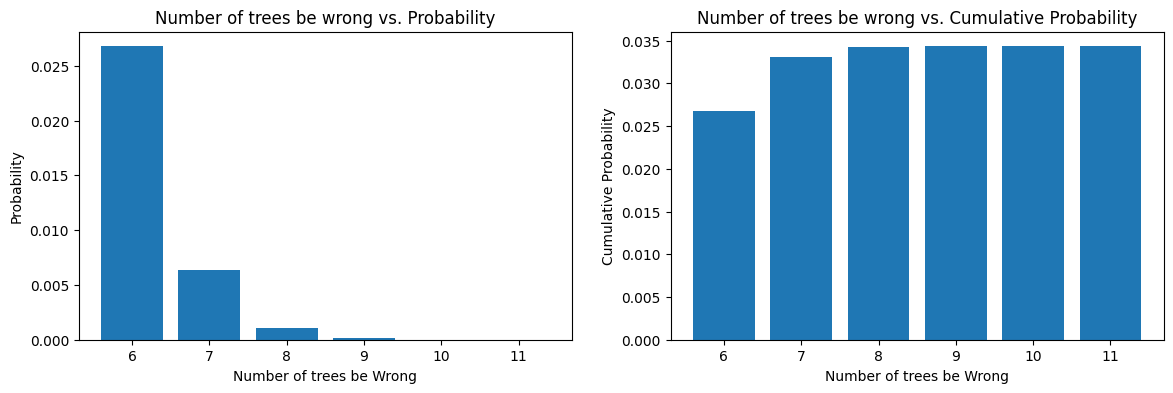

In [2]:
p = 0.25 # probability to be wrong
n = 11 # total trees
k = math.ceil(n/2) # minimal number of trees to be wrong for majority voting

factorial_list = [] # list to store probability for each tree

# since order doesn't matter, we use factorial function
for i in range(k, n+1):
    factorial_ind = math.factorial(n) / (math.factorial(n-i) * math.factorial(i)) * (p)**i * (1-p)**(n-i)
    factorial_list.append(factorial_ind)

print(f'Cumulative Probability: {np.sum(factorial_list):.4f}')

# plot the results
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].bar(np.arange(k,n+1), factorial_list)
axes[0].set_xlabel('Number of trees be Wrong')
axes[0].set_ylabel("Probability")
axes[0].set_title('Number of trees be wrong vs. Probability')

axes[1].bar(np.arange(k,n+1), np.cumsum(factorial_list))
axes[1].set_xlabel('Number of trees be Wrong')
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title('Number of trees be wrong vs. Cumulative Probability')

plt.show()

`Scenarios 2:`
- p < 0.25
- n median size (like 200)

Cumulative Probability: 0.000000000000027


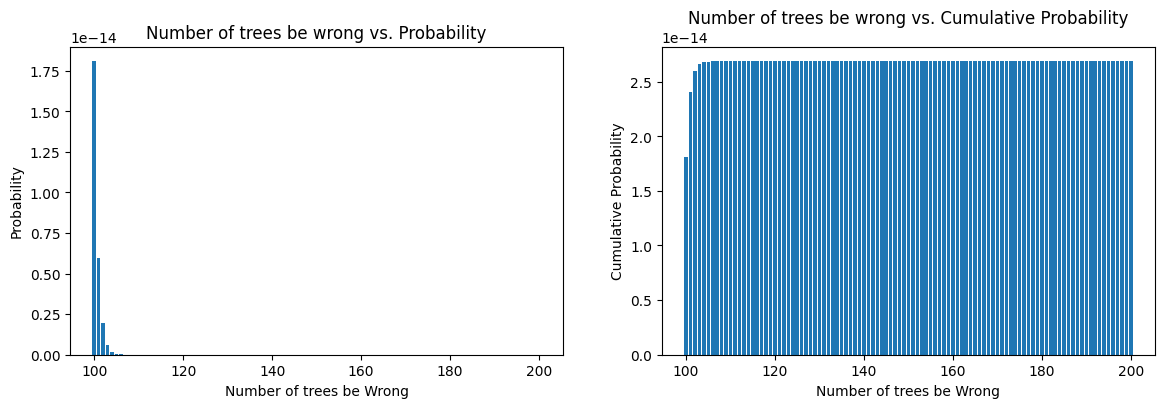

In [3]:
p = 0.25 # probability to be wrong
n = 200 # total trees
k = math.ceil(n/2) # minimal number of trees to be wrong for majority voting

factorial_list = [] # list to store probability for each tree

# since order doesn't matter, we use factorial function
for i in range(k, n+1):
    factorial_ind = math.factorial(n) / (math.factorial(n-i) * math.factorial(i)) * (p)**i * (1-p)**(n-i)
    factorial_list.append(factorial_ind)

print(f'Cumulative Probability: {np.sum(factorial_list):.15f}')

# plot the results
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].bar(np.arange(k,n+1), factorial_list)
axes[0].set_xlabel('Number of trees be Wrong')
axes[0].set_ylabel("Probability")
axes[0].set_title('Number of trees be wrong vs. Probability')

axes[1].bar(np.arange(k,n+1), np.cumsum(factorial_list))
axes[1].set_xlabel('Number of trees be Wrong')
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title(f'Number of trees be wrong vs. Cumulative Probability')

plt.show()

`Scenarios 3:`
- p > 0.5
- n median size (like 200)

Cumulative Probability: 0.983238313496839


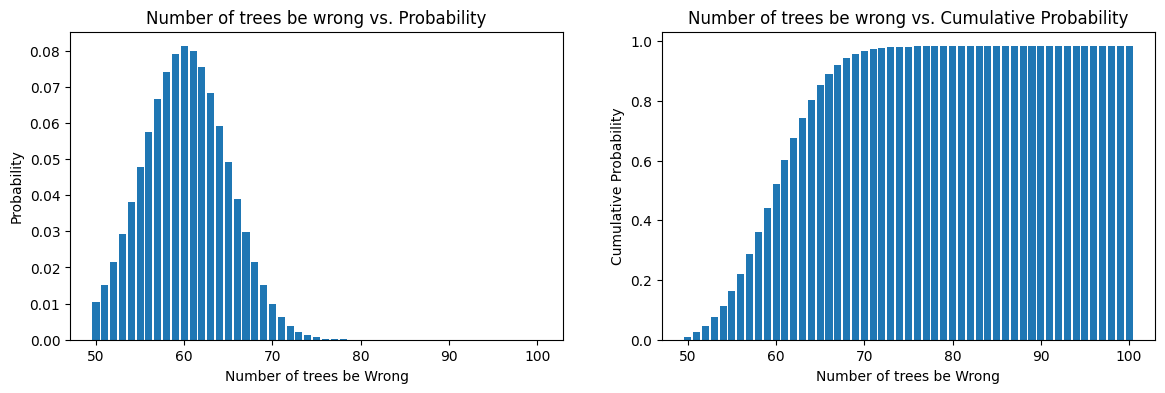

In [4]:
p = 0.6 # probability to be wrong
n = 100 # total trees
k = math.ceil(n/2) # minimal number of trees to be wrong for majority voting

factorial_list = [] # list to store probability for each tree

# since order doesn't matter, we use factorial function
for i in range(k, n+1):
    factorial_ind = math.factorial(n) / (math.factorial(n-i) * math.factorial(i)) * (p)**i * (1-p)**(n-i)
    factorial_list.append(factorial_ind)

print(f'Cumulative Probability: {np.sum(factorial_list):.15f}')

# plot the results
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].bar(np.arange(k,n+1), factorial_list)
axes[0].set_xlabel('Number of trees be Wrong')
axes[0].set_ylabel("Probability")
axes[0].set_title('Number of trees be wrong vs. Probability')

axes[1].bar(np.arange(k,n+1), np.cumsum(factorial_list))
axes[1].set_xlabel('Number of trees be Wrong')
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title(f'Number of trees be wrong vs. Cumulative Probability')

plt.show()

#### `How the Base Error affect the Ensemble Error`
- as long as the Base Error is less than 0.5, the Ensemble Strategy would benefit. (lower than the Base Error)
- the smaller the Base Error the better.

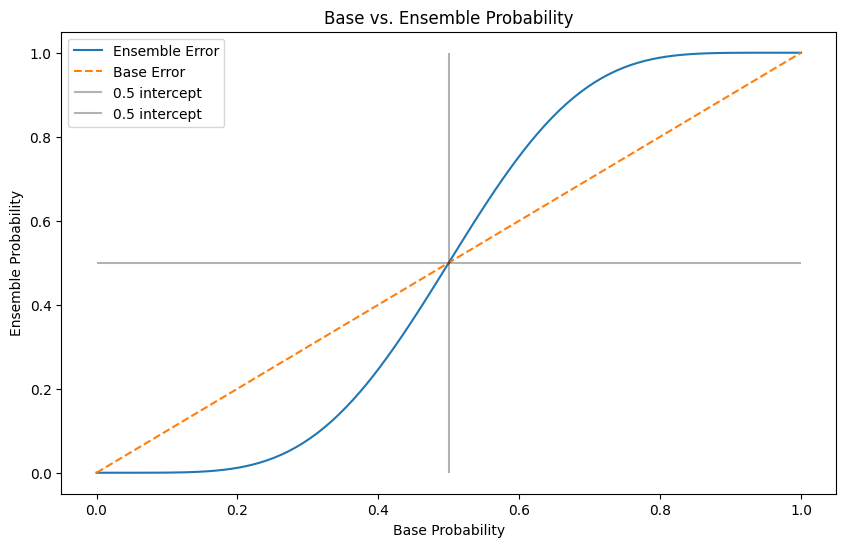

In [5]:
n = 11 # total trees
k = math.ceil(n/2) # minimal number of trees to be wrong for majority voting
p_list = np.linspace(0,1,100)

factorial_cum = [] # list to store cumulative sum

# since order doesn't matter, we use factorial function
for p in p_list:
    factorial_list = [] # list to store probability for each tree
    for i in range(k, n+1):
        factorial_ind = math.factorial(n) / (math.factorial(n-i) * math.factorial(i)) * (p)**i * (1-p)**(n-i)
        factorial_list.append(factorial_ind)
    factorial_cum.append(np.sum(factorial_list))

# plot the results
fig, axes = plt.subplots(1,1, figsize=(10,6))
plt.plot(p_list.tolist(), factorial_cum, label='Ensemble Error')
plt.plot([0,1],[0,1], '--', label='Base Error')

plt.hlines(0.5, xmin=0, xmax=1, alpha=0.3, color='k', label='0.5 intercept')
plt.vlines(0.5, ymin=0, ymax=1, alpha=0.3, color='k', label='0.5 intercept')

plt.xlabel('Base Probability')
plt.ylabel("Ensemble Probability")
plt.title('Base vs. Ensemble Probability')
plt.legend(loc='best')

plt.show()

##
##

### Using the majority voting principle to make predictions

`load and split data, train three models`

In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [7]:
iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:] # only use two features: sepal width and petal length, and two classes: versicolor and virginica
le = LabelEncoder()
y = le.fit_transform(y) # convert classes from string to categorical numbers

In [8]:
# split data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.5, 
                                                    random_state=1,
                                                    stratify=y) # stratify: keep the classes as the same percentage after split

In [9]:
# build three different models
# - Logistic regression classifier
# - Decision tree classifier
# - k-nearest neighbors classifer

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [10]:
clf1 = LogisticRegression(l1_ratio=0, # only use 'l2'
                          solver='lbfgs',
                          C=0.001, # small C mean high regularization
                          random_state=1)

clf2 = DecisionTreeClassifier(max_depth=1,
                              criterion='entropy',
                              random_state=0)

clf3 = KNeighborsClassifier(n_neighbors=1,
                            p = 2, # p = 2: use the Euclidean distance
                            metric='minkowski')

In [11]:
# pipe1 and pipe2 are used to standardlize the x value, because both Logistic regression and knn need standardlized data
pipe1 = Pipeline([
    ['sc', StandardScaler()],
    ['clf', clf1]
])

pipe3 = Pipeline([
    ['sc', StandardScaler()],
    ['clf', clf3]
])

clf_labels = ['Logistic regression', 'Decision tree', 'KNN']
print('10-fold cross validation:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(
        estimator=clf,
        X=X_train,
        y=y_train,
        cv=10,
        scoring='roc_auc'
    )
    print('ROC AUC: %0.2f (+/- %0.2f) [%s]'
          % (scores.mean(), scores.std(), label))

10-fold cross validation:

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]


`train the VotingClassifer - Majority Voting`

In [12]:
from sklearn.ensemble import VotingClassifier
mv_clf = VotingClassifier(
    estimators=[('lr', pipe1), ('dt', clf2), ('knn',pipe3)], # need a list of tuple with names and models
    voting='soft' # 'soft' uses weighted probabilites, 'hard' uses majority rule
)

clf_labels += ['Majority voting'] # all labels
all_clf = [pipe1, clf2, pipe3, mv_clf] # all models

# cross_val_score for each model
for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(
        estimator=clf,
        X=X_train,
        y=y_train,
        cv=10,
        scoring='roc_auc'
    )
    print('ROC AUC: %0.2f (+/- %0.2f) [%s]'
          % (scores.mean(), scores.std(), label))

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]
ROC AUC: 0.98 (+/- 0.05) [Majority voting]


As we can see the VotingClassifier using the Majority Voting improved the model performance

### Evaluating and tuning the ensemble classifier

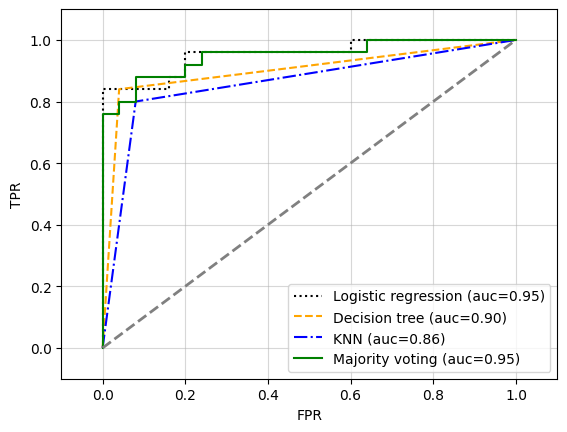

In [13]:
from sklearn.metrics import roc_curve, auc

colors = ['black','orange','blue', 'green']
linestyles = [':','--','-.','-']

for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyles):
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:,1] # predict probability for class 1, roc_curve is for binary classes
    fpr, tpr, thresholds = roc_curve(y_true = y_test,
                                     y_score=y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label=f'{label:s} (auc={roc_auc:.2f})')

plt.legend(loc='best')
plt.plot([0,1],[0,1], '--', color='gray', linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

`Classification Boundary`

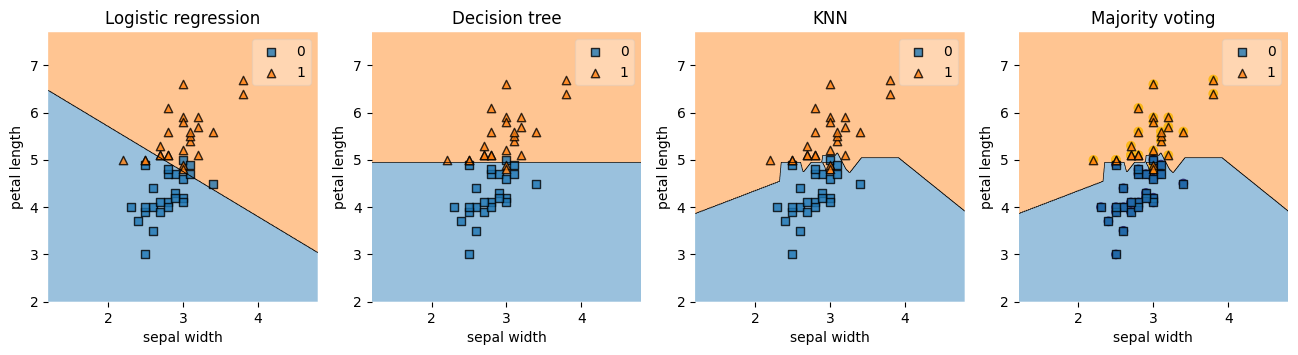

In [14]:
from mlxtend.plotting import plot_decision_regions

fig, axes = plt.subplots(1,4, figsize=(16,3.5), sharey=True)

plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
for i, (clf, label) in enumerate(zip(all_clf,clf_labels)):
    plot_decision_regions(X = X_train, y = y_train, clf=clf, ax=axes[i])
    axes[i].set_title(f'{label}')
    axes[i].set_ylabel('petal length')
    axes[i].set_xlabel('sepal width')

we can see the logistic regression can split the data well using a line (purely lucky on the data split)

`GridSearchCV`

In [15]:
mv_clf.get_params()

{'estimators': [('lr',
   Pipeline(steps=[('sc', StandardScaler()),
                   ['clf',
                    LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]])),
  ('dt',
   DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)),
  ('knn',
   Pipeline(steps=[('sc', StandardScaler()),
                   ['clf', KNeighborsClassifier(n_neighbors=1)]]))],
 'flatten_transform': True,
 'n_jobs': None,
 'verbose': False,
 'voting': 'soft',
 'weights': None,
 'lr': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf',
                  LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]]),
 'dt': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 'knn': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'lr__memory': None,
 'lr__steps': [('sc', StandardScaler()),
  ['clf', LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]],
 'lr__transform_input': None,
 'l

In [16]:
from sklearn.model_selection import GridSearchCV

In [17]:
params = {
    'dt__max_depth':[1, 2], # need to use 'dt' the model name in VotingClassifier
    'lr__clf__C':[0.001,0.1, 100.0]
}

In [18]:
grid = GridSearchCV(estimator=mv_clf,
                    param_grid=params,
                    cv=10,
                    scoring='roc_auc')

In [19]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",VotingClassif...voting='soft')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__max_depth': [1, 2], 'lr__clf__C': [0.001, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

`GridSearchCV Result`

In [20]:
grid.cv_results_

{'mean_fit_time': array([0.00163691, 0.00134783, 0.00172467, 0.00161834, 0.00161958,
        0.00190482]),
 'std_fit_time': array([3.00747419e-04, 5.60122122e-05, 4.01919487e-04, 1.70455839e-04,
        2.02692814e-04, 1.24445555e-04]),
 'mean_score_time': array([0.00078442, 0.00065513, 0.00073733, 0.00071702, 0.00076804,
        0.00081048]),
 'std_score_time': array([2.06881928e-04, 5.02262337e-05, 1.37151671e-04, 8.75981267e-05,
        9.32428331e-05, 4.39110068e-05]),
 'param_dt__max_depth': masked_array(data=[1, 1, 1, 2, 2, 2],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_lr__clf__C': masked_array(data=[0.001, 0.1, 100.0, 0.001, 0.1, 100.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'dt__max_depth': 1, 'lr__clf__C': 0.001},
  {'dt__max_depth': 1, 'lr__clf__C': 0.1},
  {'dt__max_depth': 1, 'lr__clf__C': 100.0},
  {'dt__max_depth': 2, 'lr__clf__C': 0.001},
  {'dt__max_

In [21]:
grid.best_params_

{'dt__max_depth': 1, 'lr__clf__C': 0.001}

In [22]:
grid.best_score_

np.float64(0.9833333333333334)

In [23]:
grid.cv_results_['mean_test_score']

array([0.98333333, 0.98333333, 0.96666667, 0.98333333, 0.98333333,
       0.96666667])

### Applying bagging to classify examples in the Wine dataset

`Load the data`

In [24]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data',
               header=None)
df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash',
                    'Magnesium', 'Total phenols',
                    'Flavanoids', 'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']

# only consider Wine classes 2 and 3
df_wine = df_wine[df_wine['Class label'] != 1]
y = df_wine['Class label'].values

X = df_wine[['Alcohol','OD280/OD315 of diluted wines']].values

In [ ]:
# categorize label y, and split data to train and test
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

`Apply BaggingClassifier`

In [64]:
# apply the BaggingClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier(
    max_depth=None, # tree can grow as deep as possible, cause overfitting
    criterion='entropy',
    random_state=1
)

bag = BaggingClassifier(
    estimator=tree,
    n_estimators=500,
    max_samples=1.0, # when it is float, scikit-lean treats it as a percentage (ratio) of the total of rows in the training dataset
    max_features=1.0, # when it is float, scikit-lean treats it as a percentage (ratio) of the total of rows in the training dataset
    bootstrap=True, # picking rows with replacement, to reduce variance by making sure the trees don't all overfit to the exact same outliers.
    bootstrap_features=False, # Sampling the columns, when False, every single tree in the ensemble has access to all the features available in the dataset.
    n_jobs=1,
    random_state=1
)

`What is estimator`

The 'estimator' is the "building block" of your ensemble. You are using it to tell the BaggingClassifier exactly what kind of model it should be replicating and diversifying.

Here is why you use a base_estimator in this context:

1. To Define the "Learner"
A BaggingClassifier (Bootstrap Aggregating) is not a machine learning algorithm itself; it is a meta-algorithm (an ensemble wrapper). It doesn't know how to learn from data; it only knows how to take multiple copies of an existing model, train them on different subsets of data, and average their results.

By passing base_estimator=tree, you are saying: "I want you to use this specific Decision Tree configuration as the foundation for all 500 estimators in my ensemble."

2. To Control the "Strength" of the Individual Models
In your code, you have set max_depth=None for the tree. This creates an unpruned, high-variance tree.

The Problem: A single unpruned tree is prone to overfitting (it's too sensitive to noise).
The Solution via Base Estimator: By passing this specific "overfit-prone" tree as the base_estimator, you are intentionally providing a model with high variance but low bias.
The BaggingClassifier then takes these 500 "overfitted" trees and averages them. The mathematical magic of Bagging is that it reduces the variance of the ensemble without increasing the bias. It "smooths out" the errors made by the individual unpruned trees.

`Accuracy score`

In [65]:
from sklearn.metrics import accuracy_score

In [66]:
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Traning accuracy as {tree_train:.2f}, Test accuracy as {tree_test:.2f}')

Traning accuracy as 1.00, Test accuracy as 0.83


In [67]:
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)
print(f'Traning accuracy as {bag_train:.2f}, Test accuracy as {bag_test:.2f}')

Traning accuracy as 1.00, Test accuracy as 0.92


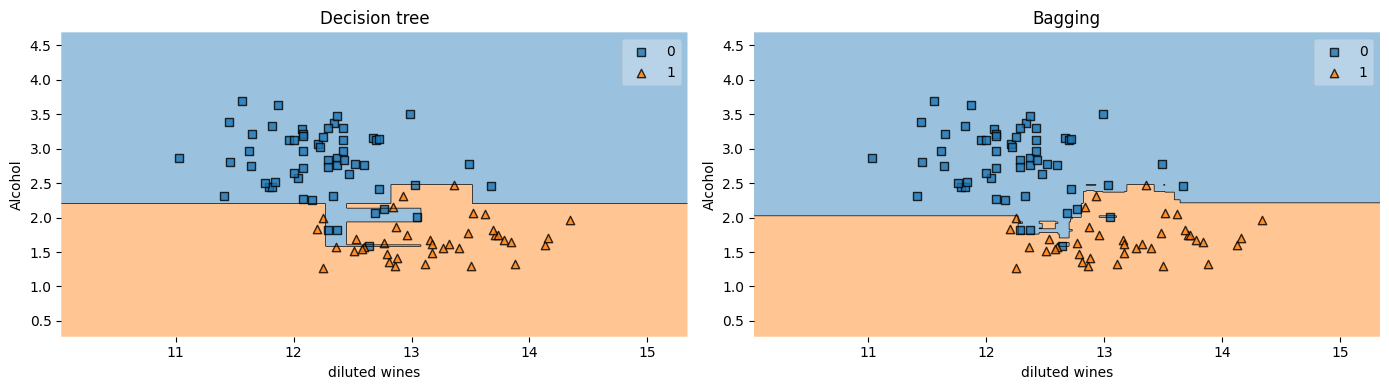

In [76]:
fig, axes = plt.subplots(1,2, figsize=(14,4), sharey=True)
plot_decision_regions(X_train, y_train, tree, ax=axes[0])
plot_decision_regions(X_train, y_train, bag, ax=axes[1])

axes[0].set_title('Decision tree')
axes[0].set_ylabel('Alcohol')
axes[0].set_xlabel('diluted wines')

axes[1].set_title('Bagging')
axes[1].set_ylabel('Alcohol')
axes[1].set_xlabel('diluted wines')

plt.tight_layout()
plt.show()

---
---

`Why average the sampling reduce the overall variance`

It comes straight out of how variance behaves under linear combinations. Start with the general formula for the variance of a sum:

$$\text{Var}\left(\sum_{b=1}^{B} X_b\right) = \sum_b \text{Var}(X_b) + \sum_{i \neq j} \text{Cov}(X_i, X_j)$$

**Case 1: i.i.d. estimators (the clean case)**

If all $\hat{f}_b$ are independent with the same variance $\sigma^2$, covariances are zero:

$$\text{Var}\left(\frac{1}{B}\sum_b \hat{f}_b\right) = \frac{1}{B^2} \sum_b \text{Var}(\hat{f}_b) = \frac{1}{B^2} \cdot B\sigma^2 = \frac{\sigma^2}{B}$$

The $\frac{1}{B^2}$ comes from pulling the constant $\frac{1}{B}$ out of the variance (constants come out squared). You sum $B$ variances, each $\sigma^2$, so you get $B\sigma^2$ in the numerator. Net effect: variance shrinks by a factor of $B$.

The intuition: independent errors partially cancel. If one model overshoots by $+\epsilon$ and another undershoots by $-\epsilon$, the average is closer to truth than either. With more independent draws, more cancellation happens. The mean is a more stable target than any individual estimate.

**Case 2: correlated estimators (the realistic case)**

Bootstrap samples overlap heavily — about 63.2% of original points appear in each bag — so the trees aren't independent. Let pairwise correlation be $\rho$, so $\text{Cov}(\hat{f}_i, \hat{f}_j) = \rho \sigma^2$. There are $B(B-1)$ off-diagonal terms:

$$\text{Var}\left(\frac{1}{B}\sum_b \hat{f}_b\right) = \frac{1}{B^2}\left[B\sigma^2 + B(B-1)\rho\sigma^2\right] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Two things to notice:

1. The second term still vanishes as $B \to \infty$ — that's the part averaging kills.
2. The first term, $\rho\sigma^2$, is a *floor*. No amount of additional trees gets you below it. If your trees are perfectly correlated ($\rho = 1$), averaging does nothing — you just keep recomputing the same prediction.

**Why this explains Random Forest's design choice**

This is exactly why Random Forest adds the random feature subset at each split on top of bootstrapping. Bootstrap alone gives you decorrelation from row sampling, but trees still tend to pick the same dominant features and look similar. Random feature selection at each split forces trees to diversify their structure, pushing $\rho$ down, which lowers that floor term $\rho\sigma^2$. Plain bagged trees have a higher $\rho$ and therefore a higher variance floor than Random Forest — same number of trees, worse variance reduction.

So "variance of the average is smaller" is really two effects layered: (1) more estimators dilute the independent noise component, and (2) lower correlation between estimators lowers the irreducible floor that dilution can't touch.

---
---

`Why averaging doesn't reduce the bias`

**The core reason: bias is a property of the expectation, and averaging preserves the expectation.**

Bias is defined as:

$$\text{Bias}(\hat{f}) = \mathbb{E}[\hat{f}(x)] - f(x)$$

where the expectation is taken over the randomness in training data. It measures: *on average across all possible training sets, how far off is my model from truth?*

Now look at what happens when you average $B$ bagged models:

$$\mathbb{E}\left[\frac{1}{B}\sum_{b=1}^{B} \hat{f}_b(x)\right] = \frac{1}{B}\sum_{b=1}^{B} \mathbb{E}[\hat{f}_b(x)]$$

This uses **linearity of expectation** — $\mathbb{E}$ passes through sums and constants unchanged. Each bootstrap sample is drawn from the same data distribution, so each $\hat{f}_b$ has the same expected prediction. Call it $\mu$. Then:

$$\frac{1}{B}\sum_{b=1}^{B} \mu = \mu$$

The ensemble's expected prediction equals the individual model's expected prediction. So the bias is unchanged:

$$\text{Bias}(\bar{f}) = \mu - f(x) = \text{Bias}(\hat{f}_b)$$

**Why variance is different:**

Variance involves *squared* deviations: $\mathbb{E}[(\hat{f} - \mathbb{E}\hat{f})^2]$. Squaring is non-linear, so the algebra doesn't collapse the same way — cross-terms appear, and when models are decorrelated, those cross-terms shrink the result. That's the $\frac{\sigma^2}{B}$ effect we derived.

**Intuition without the algebra:**

Bias is *systematic* error — every bootstrap sample comes from the same true distribution, so every base learner inherits the same systematic blind spots (e.g., a tree of depth 3 cannot represent a complex nonlinear boundary, period; resampling doesn't grant it more capacity). Averaging things that all lean the same direction gives you something that still leans that direction.

Variance is *random* error — the part that flips sign between training runs. Independent errors partially cancel when averaged. Systematic errors don't cancel; they reinforce.

So: averaging the *predictions* of bagged models reduces variance but not bias. Was this the question, or did you mean something else (e.g., why boosting reduces bias, or why subsampling rows in some other setup affects bias)?

---
---

## Leveraging weak learners via adaptive boosting

`Why AdaBoost trend to overfit the train data`

AdaBoost (Adaptive Boosting) tends to overfit because its fundamental mechanism is designed to **prioritize mistakes**. While Bagging focuses on smoothing out variance, Boosting focuses on reducing bias by aggressively attacking the errors of previous models.

Here are the specific reasons why this leads to overfitting:

### 1. The Weighting Mechanism (Focus on Hard Examples)
The core logic of AdaBoost is to increase the weights of data points that were misclassified by the previous weak learner. 
*   In the first iteration, all points have equal weight.
*   In subsequent iterations, the algorithm "zoots in" on the samples that are difficult to classify.

**The Overfitting Trap:** Eventually, the algorithm begins to assign massive weights to **outliers** or **noisy data points**. Because these points are mathematically "impossible" or extremely difficult to classify correctly, the next weak learner will distort its decision boundary specifically to capture those outliers. This results in a model that fits the noise of the training set rather than the underlying pattern.

### 2. Sequential Error Minimization
Unlike Bagging, where models are independent, AdaBoost is **sequential**. Each new model is a direct response to the failures of the predecessor. 
*   If you have too many iterations (too many weak learners), the ensemble becomes increasingly complex.
*   The "margin" of error for the training set shrinks toward zero. 
*   As the training error approaches zero, the model begins to create highly complex, jagged decision boundaries to ensure every single training point (including noise) is correctly categorized.

### 3. Lack of "Smoothing"
In Bagging, the averaging process acts as a regularizer; it smooths out the predictions. In AdaBoost, there is no such smoothing effect. Each new learner adds a new layer of complexity to the decision boundary. If the boosting process continues for too many rounds, the cumulative decision boundary becomes so intricate that it captures every "bump" in the training data, losing its ability to generalize to unseen data.

---

### How to Prevent Overfitting in AdaBoost

If you find your AdaBoost model is overfitting, you can use these common strategies:

1.  **Reduce the Number of Estimators ($T$):** This is the most effective method. Stop the boosting process before it starts focusing on outliers (often implemented via **Early Stopping**).
2.  **Decrease the Learning Rate ($\eta$):** A smaller learning rate means each weak learner has a smaller impact on the final model. While this requires more iterations, it makes the "attack" on errors much slower and more controlled, preventing the model from reacting too violently to noise.
3.  **Use Stronger Weak Learners:** While AdaBoost is designed for "weak" learners (like decision stumps), using a slightly more complex base learner with a very low learning rate can sometimes provide better stability.
4.  **Data Cleaning:** Since AdaBoost is highly sensitive to outliers, cleaning your training set of noisy labels or extreme outliers can significantly reduce the risk of overfitting.

### Summary Comparison
| Feature | Bagging (e.g., Random Forest) | Boosting (e.g., AdaBoost) |
| :--- | :--- | :--- |
| **Primary Goal** | Reduce Variance | Reduce Bias |
| **Handling Noise** | Robust (averages it out) | Sensitive (weights it higher) |
| **Risk of Overfitting** | Low | **High** |


---
---

## Applying AdaBoost using scikit-learn

In [77]:
from sklearn.ensemble import AdaBoostClassifier

In [80]:
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)
ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)

tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train , y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'tree_train accuracy {tree_train:.4f}, tree_test accuracy {tree_test:.4f}')

tree_train accuracy 0.9158, tree_test accuracy 0.8750


In [81]:
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
ada_train = accuracy_score(y_train , y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)
print(f'ada_train accuracy {ada_train:.4f}, ada_test accuracy {ada_test:.4f}')

ada_train accuracy 0.9684, ada_test accuracy 0.9167


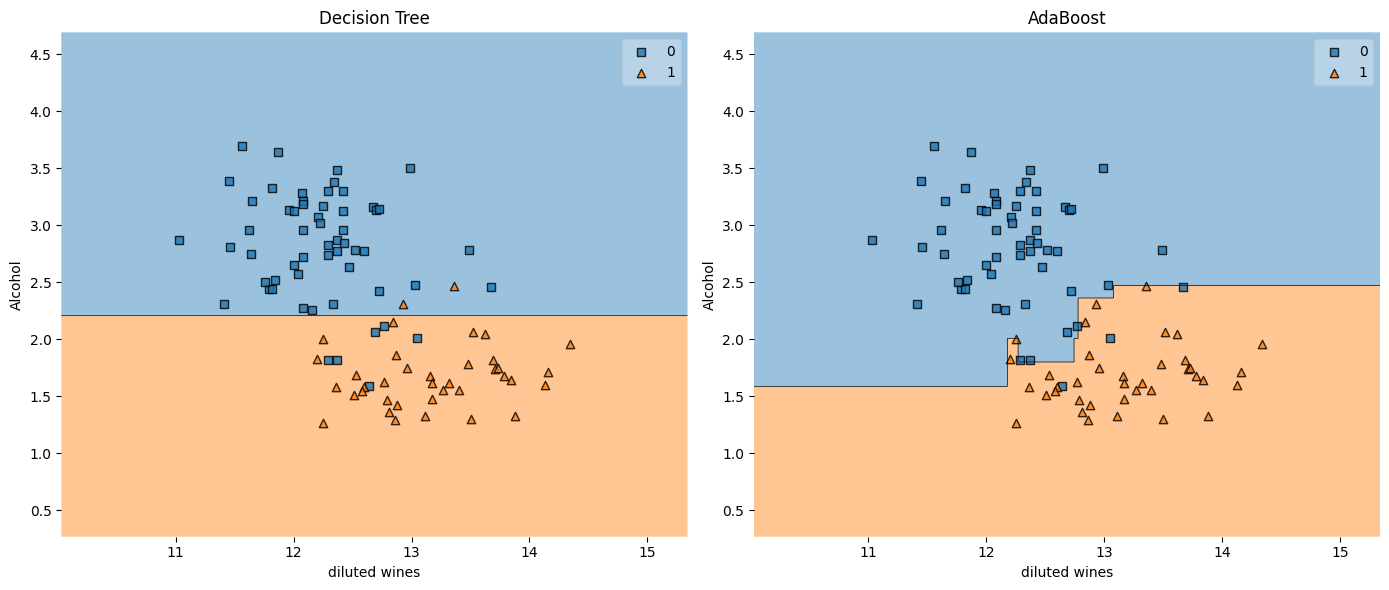

In [85]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
plot_decision_regions(X_train, y_train, tree, ax = axes[0])
plot_decision_regions(X_train, y_train, ada, ax = axes[1])

axes[0].set_title('Decision Tree')
axes[0].set_xlabel('diluted wines')
axes[0].set_ylabel('Alcohol')

axes[1].set_title('AdaBoost')
axes[1].set_xlabel('diluted wines')
axes[1].set_ylabel('Alcohol')

plt.tight_layout()
plt.show()